# 01 — Exploratory Data Analysis

Phase 1 of the E-Commerce Product Return Risk Prediction System.

**Data:** `dataset/raw/train.csv` read **as-is** (no cleaning, clipping, encoding, or scaling).

**Contract:** `docs/data-dictionary.md` (Phase 0). This notebook does **not** change the dictionary or schemas.

**Figures:** `reports/figures/`

Known sign issues (Phase 0) — still present in the raw file:

| Column | Negatives (documented) | Decision |
|--------|------------------------|----------|
| `product_price` | 27,285 | Fix later (`abs` / clip to 0) |
| `discount_percent` | 1,686 | Fix later |
| `past_return_rate` | 2,220 | Fix later (rate must be 0–1) |
| `session_length_minutes` | 1,487 | Fix later |
| `num_product_views` | 21,443 | Fix later |
| `delivery_delay_days` | 78,564 | **Keep signed** (early vs late) |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pointbiserialr

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titlesize"] = 11

ROOT = Path.cwd()
if not (ROOT / "dataset" / "raw" / "train.csv").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "dataset" / "raw" / "train.csv"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_PREDICTORS = [
    "customer_age",
    "product_price",
    "discount_percent",
    "product_rating",
    "past_purchase_count",
    "past_return_rate",
    "delivery_delay_days",
    "session_length_minutes",
    "num_product_views",
]
CATEGORICAL_PREDICTORS = [
    "device_type",
    "product_category",
    "shipping_method",
    "payment_method",
]
BINARY_DISPLAY = ["used_coupon", "returned"]

# Phase 0 documented negative counts (cross-check only)
DOCUMENTED_NEGATIVES = {
    "product_price": 27285,
    "discount_percent": 1686,
    "past_return_rate": 2220,
    "delivery_delay_days": 78564,
    "session_length_minutes": 1487,
    "num_product_views": 21443,
}
NEGATIVE_NOTE = {
    "customer_age": "no known sign issue",
    "product_price": "invalid negatives — fix later",
    "discount_percent": "invalid negatives — fix later",
    "product_rating": "no known sign issue",
    "past_purchase_count": "no known sign issue",
    "past_return_rate": "invalid negatives — fix later",
    "delivery_delay_days": "negatives KEPT (early delivery)",
    "session_length_minutes": "invalid negatives — fix later",
    "num_product_views": "invalid negatives — fix later",
}

print("ROOT:", ROOT)
print("DATA:", DATA_PATH)

ROOT: g:\SLIIT Academy\6th Semester\FDM\FDM Project\FDM_Project
DATA: g:\SLIIT Academy\6th Semester\FDM\FDM Project\FDM_Project\dataset\raw\train.csv


## 1. Load and profile

Confirm shape, dtypes, and that there are no missing values. Raw file is not modified.

In [2]:
df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print("\ndtypes:")
print(df.dtypes.to_string())
print("\nmissing values per column:")
print(df.isna().sum().to_string())
print("\ntotal missing cells:", int(df.isna().sum().sum()))
print("duplicate rows:", int(df.duplicated().sum()))
print("unique order_id:", df["order_id"].nunique(), "/", len(df))
print("\nreturned class balance:")
print(df["returned"].value_counts().sort_index())
print((df["returned"].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")
df.head()

shape: (200000, 16)

dtypes:
customer_age                int64
product_price             float64
discount_percent          float64
product_rating            float64
past_purchase_count         int64
past_return_rate          float64
delivery_delay_days       float64
session_length_minutes    float64
num_product_views           int64
device_type                   str
product_category              str
shipping_method               str
payment_method                str
used_coupon                 int64
returned                    int64
order_id                    int64

missing values per column:
customer_age              0
product_price             0
discount_percent          0
product_rating            0
past_purchase_count       0
past_return_rate          0
delivery_delay_days       0
session_length_minutes    0
num_product_views         0
device_type               0
product_category          0
shipping_method           0
payment_method            0
used_coupon               0
returne

duplicate rows: 0
unique order_id: 200000 / 200000

returned class balance:
returned
0    105081
1     94919
Name: count, dtype: int64
returned
0    52.54%
1    47.46%
Name: proportion, dtype: str


,customer_age,product_price,discount_percent,product_rating,past_purchase_count,past_return_rate,delivery_delay_days,session_length_minutes,num_product_views,device_type,product_category,shipping_method,payment_method,used_coupon,returned,order_id
0,25,11.666137,43.559601,1.933533,8,0.331408,-0.089637,3.273029,26,tablet,sports,express,paypal,1,0,75381
1,76,31.378967,66.526039,0.690237,9,0.105203,3.639277,130.513123,8,mobile,electronics,standard,credit_card,1,0,65569
2,40,25.460603,20.762374,2.347620,14,0.236683,0.294060,92.780917,-2,desktop,toys,express,credit_card,0,0,163473
3,62,13.517170,25.669260,2.033596,9,0.410038,1.683333,103.004177,7,mobile,clothing,express,apple_pay,0,0,90518
4,51,75.771311,15.527927,4.907556,9,0.123565,-0.153691,100.752658,6,mobile,electronics,standard,credit_card,1,0,138866


## 2. Univariate analysis — numeric histograms

Each title notes the Phase 0 sign decision. Red dashed line is 0, so invalid (or signed) negatives are visible. Data are **not** transformed.

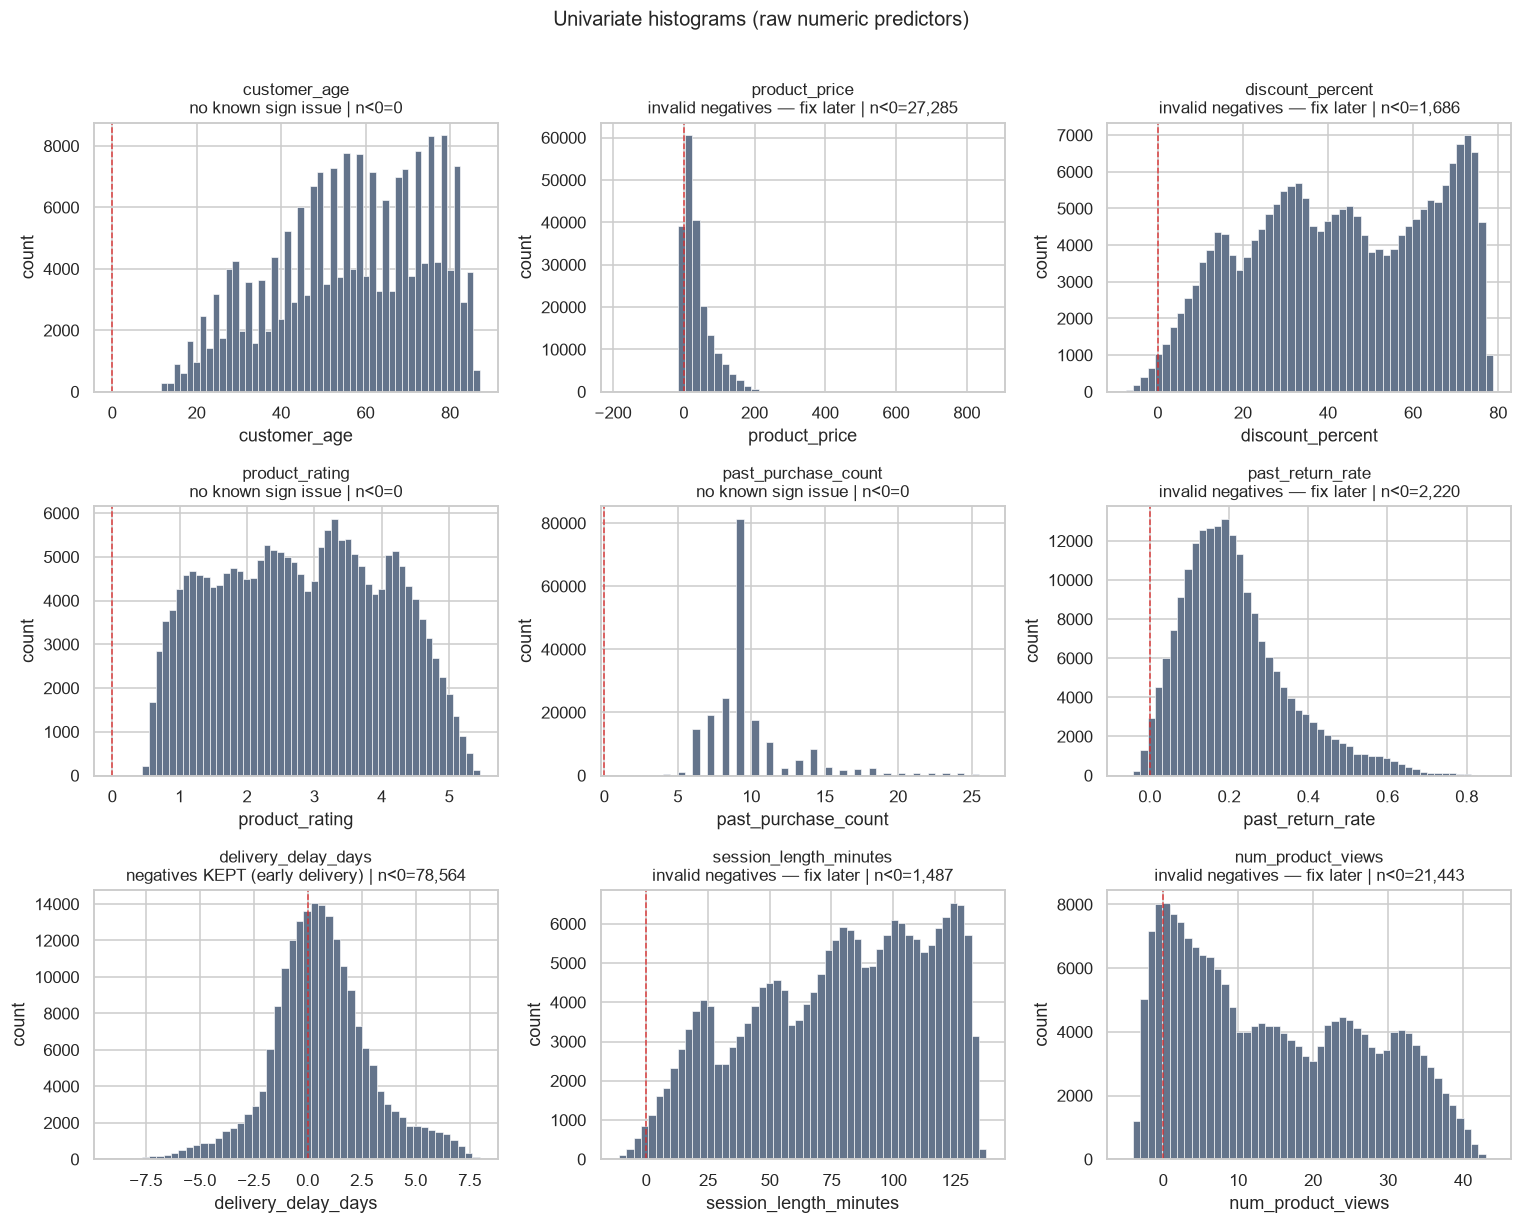

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.ravel(), NUMERIC_PREDICTORS):
    ax.hist(df[col], bins=50, color="#64748b", edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="#dc2626", linestyle="--", linewidth=1, alpha=0.85)
    n_neg = int((df[col] < 0).sum())
    ax.set_title(f"{col}\n{NEGATIVE_NOTE[col]} | n<0={n_neg:,}")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
fig.suptitle("Univariate histograms (raw numeric predictors)", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_numeric_histograms.png", bbox_inches="tight")
plt.show()

## 2b. Univariate analysis — categorical and binary bars

`device_type`, `product_category`, `shipping_method`, `payment_method`, plus `used_coupon` and the target `returned`.

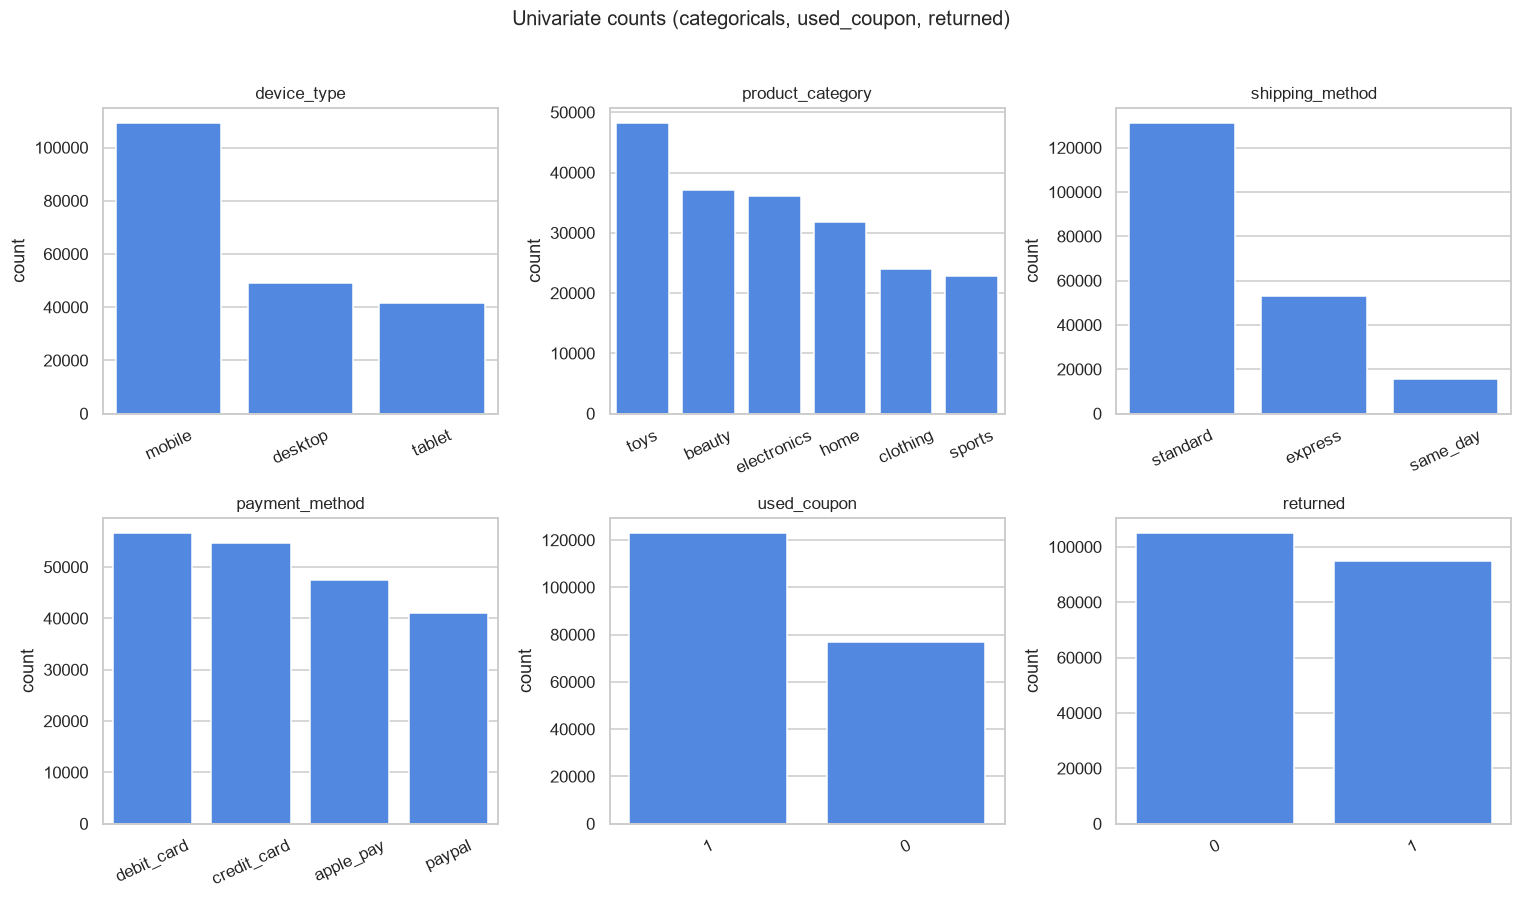

In [4]:
bar_cols = CATEGORICAL_PREDICTORS + BINARY_DISPLAY
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), bar_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, color="#3b82f6")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=25)
    ax.set_xlabel("")
fig.suptitle("Univariate counts (categoricals, used_coupon, returned)", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_categorical_bars.png", bbox_inches="tight")
plt.show()

## 3. Bivariate analysis vs `returned`

### 3a. Numeric predictors — boxplots by target

Boxes compare `returned = 0` vs `1` on the **raw** scale (negatives still included). Fliers omitted so the box (median / IQR) is readable at n = 200,000; tails are quantified in section 5.

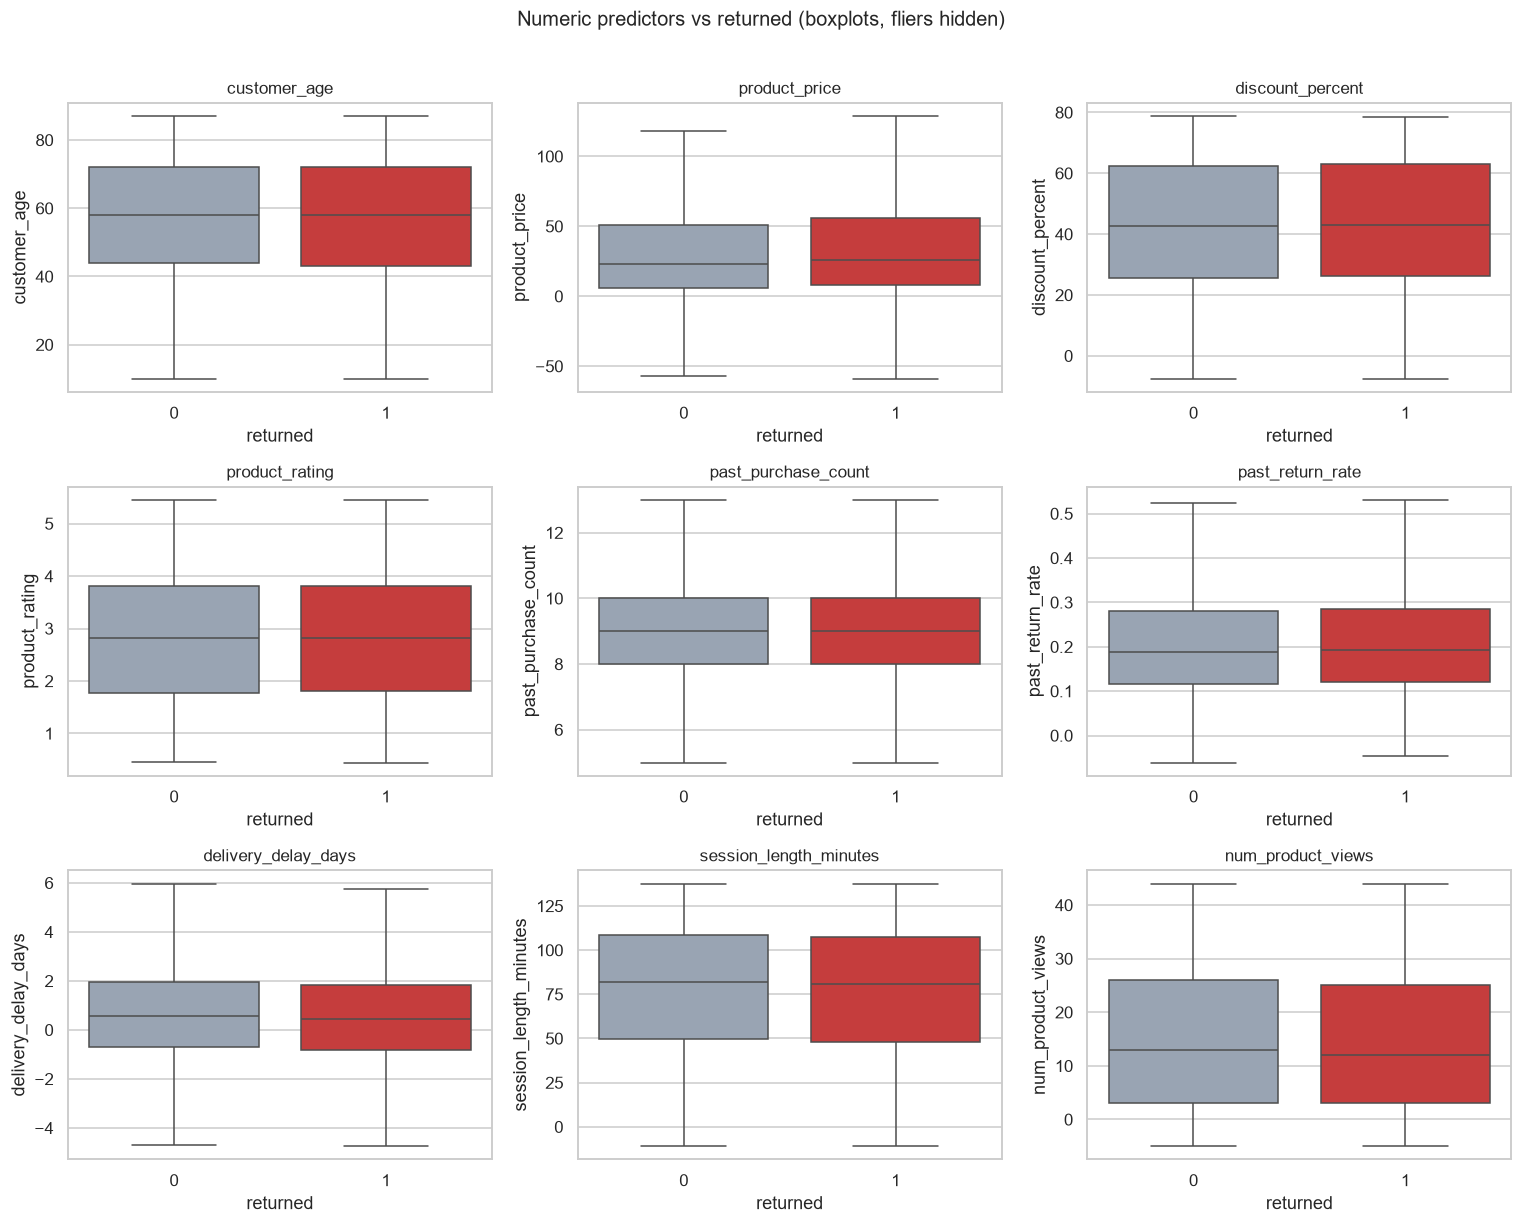

Group means (raw):


returned,0,1
customer_age,56.6738,56.2645
product_price,36.4957,39.6321
discount_percent,42.6318,43.1380
product_rating,2.8075,2.8187
past_purchase_count,9.6910,9.5419
past_return_rate,0.2128,0.2177
delivery_delay_days,0.6950,0.5476
session_length_minutes,78.0055,76.7426
num_product_views,14.8811,14.4035


Group medians (raw):


returned,0,1
customer_age,58.0000,58.0000
product_price,23.2624,25.8466
discount_percent,42.8257,43.0562
product_rating,2.8201,2.8175
past_purchase_count,9.0000,9.0000
past_return_rate,0.1892,0.1936
delivery_delay_days,0.5857,0.4450
session_length_minutes,82.2408,80.7586
num_product_views,13.0000,12.0000


In [5]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.ravel(), NUMERIC_PREDICTORS):
    sns.boxplot(
        data=df,
        x="returned",
        y=col,
        ax=ax,
        showfliers=False,
        hue="returned",
        palette={0: "#94a3b8", 1: "#dc2626"},
        legend=False,
    )
    ax.set_title(col)
    ax.set_xlabel("returned")
fig.suptitle("Numeric predictors vs returned (boxplots, fliers hidden)", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_numeric_boxplots_by_returned.png", bbox_inches="tight")
plt.show()

print("Group means (raw):")
display(df.groupby("returned")[NUMERIC_PREDICTORS].mean().T.round(4))
print("Group medians (raw):")
display(df.groupby("returned")[NUMERIC_PREDICTORS].median().T.round(4))

### 3b. Categorical predictors — return rate by level

Bar height = `mean(returned)` = empirical return rate. Includes `used_coupon` (binary predictor).

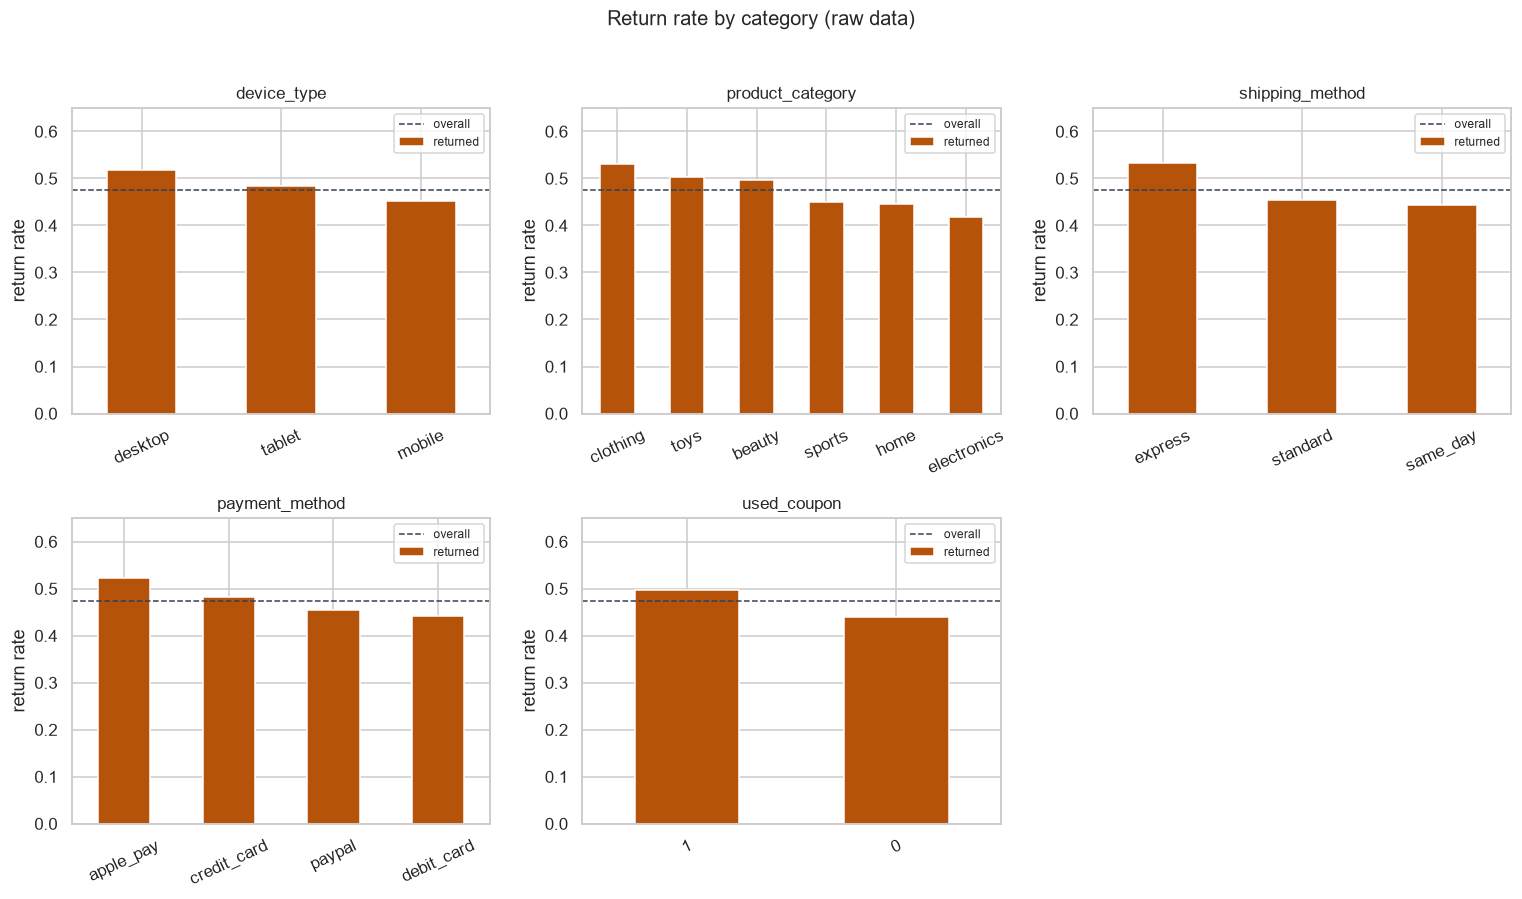

Return rate by level (max − min gap):

device_type  gap=0.0679
device_type
desktop    0.5191
tablet     0.4838
mobile     0.4512

product_category  gap=0.1131
product_category
clothing       0.5305
toys           0.5031
beauty         0.4972
sports         0.4504
home           0.4454
electronics    0.4173

shipping_method  gap=0.0893
shipping_method
express     0.5322
standard    0.4551
same_day    0.4429

payment_method  gap=0.0799
payment_method
apple_pay      0.5217
credit_card    0.4821
paypal         0.4554
debit_card     0.4418

used_coupon  gap=0.0564
used_coupon
1    0.4963
0    0.4399


In [6]:
cat_for_rate = CATEGORICAL_PREDICTORS + ["used_coupon"]
rate_tables = {}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, col in enumerate(cat_for_rate):
    rates = df.groupby(col)["returned"].mean().sort_values(ascending=False)
    rate_tables[col] = rates
    rates.plot(kind="bar", ax=axes[i], color="#b45309", rot=25)
    axes[i].set_ylim(0, 0.65)
    axes[i].axhline(df["returned"].mean(), color="#334155", linestyle="--", linewidth=1, label="overall")
    axes[i].set_title(col)
    axes[i].set_ylabel("return rate")
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)
axes[-1].axis("off")
fig.suptitle("Return rate by category (raw data)", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_return_rate_by_category.png", bbox_inches="tight")
plt.show()

print("Return rate by level (max − min gap):")
for col, rates in rate_tables.items():
    gap = float(rates.max() - rates.min())
    print(f"\n{col}  gap={gap:.4f}")
    print(rates.round(4).to_string())

### 3c. Visual separation vs `returned`

Numeric boxplots sit almost on top of each other: group means differ only slightly (strongest numeric shifts are `product_price` a bit higher for returns, `delivery_delay_days` a bit **lower** / more early for returns). That is weak visual separation.

Categorical return-rate bars separate more clearly:

1. **`product_category`** — largest gap (~11 pp): clothing highest, electronics lowest.
2. **`shipping_method`** — express well above standard / same_day.
3. **`payment_method`** — apple_pay highest, debit_card lowest.
4. **`device_type`** — desktop highest, mobile lowest.
5. **`used_coupon`** — coupon users return more often than non-users.

So **category / coupon fields look more useful than any single numeric** on a raw bivariate view. Confirm with correlations next.

## 4. Correlation analysis

- Heatmap: **numeric predictors only** (`order_id` excluded; target not on the heatmap).
- Point-biserial: each numeric predictor vs binary `returned`.

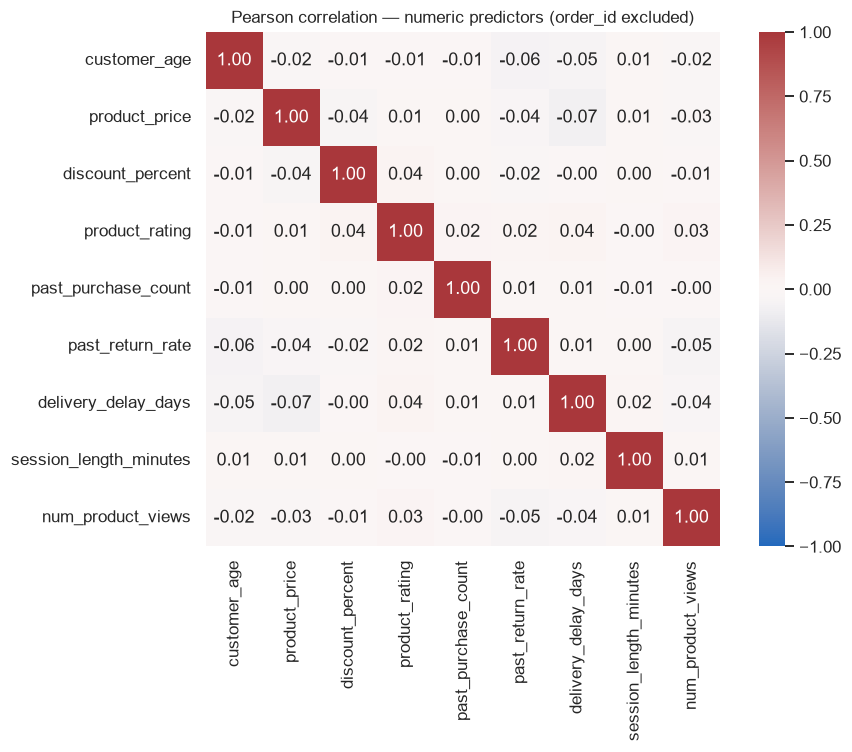

Point-biserial correlation with returned (raw values):


,predictor,point_biserial_r,p_value
1,product_price,0.0343,3.26e-53
6,delivery_delay_days,-0.0316,2.63e-45
4,past_purchase_count,-0.0237,2.90e-26
8,num_product_views,-0.0188,3.55e-17
5,past_return_rate,0.0180,7.85e-16
7,session_length_minutes,-0.0173,9.18e-15
2,discount_percent,0.0118,1.48e-07
0,customer_age,-0.0114,3.55e-07
3,product_rating,0.0046,4.17e-02


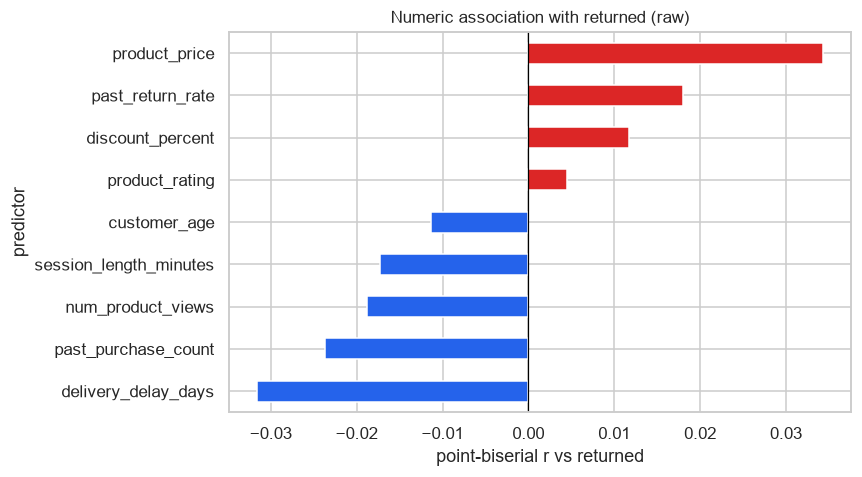

In [7]:
corr = df[NUMERIC_PREDICTORS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    square=True,
)
ax.set_title("Pearson correlation — numeric predictors (order_id excluded)")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_numeric_correlation_heatmap.png", bbox_inches="tight")
plt.show()

rows = []
for col in NUMERIC_PREDICTORS:
    r, p = pointbiserialr(df[col], df["returned"])
    rows.append({"predictor": col, "point_biserial_r": r, "p_value": p, "abs_r": abs(r)})
pb = pd.DataFrame(rows).sort_values("abs_r", ascending=False).drop(columns="abs_r")
print("Point-biserial correlation with returned (raw values):")
display(pb.style.format({"point_biserial_r": "{:.4f}", "p_value": "{:.2e}"}))

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_pb = pb.set_index("predictor")["point_biserial_r"].sort_values()
plot_pb.plot(kind="barh", ax=ax, color=np.where(plot_pb >= 0, "#dc2626", "#2563eb"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("point-biserial r vs returned")
ax.set_title("Numeric association with returned (raw)")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_point_biserial_vs_returned.png", bbox_inches="tight")
plt.show()

## 5. Outlier and range summary

For each numeric column (predictors + `returned` / `order_id` called out separately): min, max, mean, median, std, % negative. `% negative` is cross-checked against Phase 0 counts. Extra flags look for problems **beyond** the known negative-value issue.

In [8]:
numeric_all = NUMERIC_PREDICTORS  # predictors only; order_id excluded from modeling stats
rows = []
n = len(df)
for col in numeric_all:
    s = df[col]
    n_neg = int((s < 0).sum())
    pct_neg = 100 * n_neg / n
    expected = DOCUMENTED_NEGATIVES.get(col)
    match = "n/a (none expected)" if expected is None else ("MATCH" if n_neg == expected else f"MISMATCH (doc={expected:,})")
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_iqr_out = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
    extra = []
    if col == "product_rating":
        extra.append(f"n<1={(s < 1).sum():,}; n>5={(s > 5).sum():,} (1–5 scale overshoot)")
    if col == "product_price":
        extra.append(f"n>200={(s > 200).sum():,}; n>500={(s > 500).sum():,}; p99={s.quantile(0.99):.1f}; max={s.max():.1f}")
    if col == "discount_percent":
        extra.append(f"n>100={(s > 100).sum():,} (none expected)")
    if col == "past_return_rate":
        extra.append(f"n>1={(s > 1).sum():,} (none expected)")
    if col == "customer_age":
        extra.append("min age 10 (young but plausible); max 87")
    if col == "delivery_delay_days":
        extra.append("signed range is expected — not an extra defect")
    rows.append(
        {
            "column": col,
            "min": s.min(),
            "max": s.max(),
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "n_negative": n_neg,
            "pct_negative": round(pct_neg, 3),
            "phase0_neg_check": match,
            "n_iqr_outliers": n_iqr_out,
            "extra_quality_flags": "; ".join(extra) if extra else "—",
        }
    )

summary = pd.DataFrame(rows)
display(
    summary.style.format(
        {
            "min": "{:.4f}",
            "max": "{:.4f}",
            "mean": "{:.4f}",
            "median": "{:.4f}",
            "std": "{:.4f}",
            "pct_negative": "{:.3f}",
        }
    )
)

print("order_id: nunique =", df["order_id"].nunique(), "min/max =", df["order_id"].min(), df["order_id"].max(), "(identifier — drop before modeling)")
print("returned: mean =", round(df["returned"].mean(), 4), "(balanced; no class-weight needed)")

summary.to_csv(ROOT / "reports" / "eda_numeric_range_summary.csv", index=False)
print("Wrote reports/eda_numeric_range_summary.csv")

,column,min,max,mean,median,std,n_negative,pct_negative,phase0_neg_check,n_iqr_outliers,extra_quality_flags
0,customer_age,10.0000,87.0000,56.4795,58.0000,17.9529,0,0.000,n/a (none expected),0,min age 10 (young but plausible); max 87
1,product_price,-183.2921,855.0786,37.9842,24.4611,45.6269,27285,13.643,MATCH,11689,"n>200=1,547; n>500=35; p99=189.3; max=855.1"
2,discount_percent,-7.5408,78.7915,42.8721,42.9452,21.5105,1686,0.843,MATCH,0,n>100=0 (none expected)
3,product_rating,0.4453,5.4527,2.8128,2.8187,1.2199,0,0.000,n/a (none expected),0,"n<1=14,280; n>5=3,831 (1–5 scale overshoot)"
4,past_purchase_count,1.0000,26.0000,9.6202,9.0000,3.1400,0,0.000,n/a (none expected),23432,—
5,past_return_rate,-0.0609,0.8664,0.2151,0.1914,0.1372,2220,1.110,MATCH,7260,n>1=0 (none expected)
6,delivery_delay_days,-9.0500,7.9613,0.6251,0.5190,2.3312,78564,39.282,MATCH,9053,signed range is expected — not an extra defect
7,session_length_minutes,-11.0105,137.6529,77.4061,81.5623,36.3942,1487,0.744,MATCH,0,—
8,num_product_views,-5.0000,44.0000,14.6545,13.0000,12.6594,21443,10.722,MATCH,0,—


order_id: nunique = 200000 min/max = 0 249999 (identifier — drop before modeling)
returned: mean = 0.4746 (balanced; no class-weight needed)
Wrote reports/eda_numeric_range_summary.csv


## 6. Phase 1 summary

### Top 5 predictors that look most useful (raw EDA)

Ranked by **visual / practical separation** of return rate (categorical gaps in pp) and, for numerics, |point-biserial r|. All numeric |r| values are **< 0.04**, so trees/boosting may still use them jointly, but they are not the headline bivariate signals.

1. **`product_category`** — clearest bar-chart gap (~11 percentage points): clothing highest return rate, electronics lowest.
2. **`shipping_method`** — express returns more than standard / same_day (~9 pp).
3. **`payment_method`** — apple_pay highest, debit_card lowest (~8 pp).
4. **`device_type`** — desktop highest, mobile lowest (~7 pp).
5. **`used_coupon`** — coupon users return more than non-users (~6 pp).

Best **numeric** associations (weaker than the five above): **`product_price`** (slightly higher among returns, r ≈ +0.034) and **`delivery_delay_days`** (slightly *more negative / earlier* among returns, r ≈ −0.032). Keep `delivery_delay_days` signed per Phase 0.

### Additional data-quality issues (beyond Phase 0 negatives)

- **`product_rating` scale overshoot:** thousands of ratings **below 1** and **above 5**. Phase 0 kept this column as-is; it is an extra plausibility issue for a typical 1–5 scale.
- **`product_price` right tail:** after the known negatives, a small number of very high prices (max ≈ 855 vs p99 ≈ 189; dozens above 500). Worth a later decision (winsorize vs keep).
- **Upper bounds that look fine:** `discount_percent` never exceeds 100; `past_return_rate` never exceeds 1.
- **Identifiers:** `order_id` is unique (200,000/200,000); no duplicate rows. Still drop `order_id` before modeling.
- **Target:** confirmed balanced (~52.5% / 47.5%); no class-weighting needed.
- **No missing values** in any column.

No preprocessing was applied in this notebook. Cleaning starts in Phase 2 using the Phase 0 decisions.